In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import pickle

from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations
from geoai.utils_ml.model_ops import ModelOperations
pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [3]:
# Note that we are loading the feature engineered data
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train_encoded.csv")
y_test = pd.read_csv("csv_files/y_test_encoded.csv")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
0,5.860786,6.297109,5.780744,8.094989,7.588999,0.599142,-0.284788,0.002541,34.348815,36.906012,...,0.019287,0.358971,-0.170628,0.001523,0.081104,-0.000724,6.459135e-06,0,1,2
1,5.968708,6.320768,5.942799,8.012239,7.596894,0.574505,-0.229186,0.002224,35.625470,37.726818,...,0.016899,0.330056,-0.131668,0.001278,0.052526,-0.000510,4.948067e-06,0,1,2
2,7.071573,7.111240,7.145984,7.234177,7.431537,0.043156,0.093877,0.000127,50.007150,50.287656,...,0.000947,0.001862,0.004051,0.000006,0.008813,0.000012,1.625104e-08,1,0,0
3,5.897703,6.305362,5.981414,8.085025,7.627057,0.578262,-0.255084,0.002435,34.782903,37.187156,...,0.018575,0.334387,-0.147505,0.001408,0.065068,-0.000621,5.931214e-06,0,1,2
4,6.999970,7.010613,7.051856,7.113956,7.361375,0.030594,0.116155,0.000098,48.999577,49.074077,...,0.000724,0.000936,0.003554,0.000003,0.013492,0.000011,9.665850e-09,1,0,0


In [4]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)

In [5]:
# apply_pca using 4 components
X_train_pca, X_test_pca = pre_ops.apply_pca(
    X_train_fe_scaled, X_test_fe_scaled, n_components=7
)

# scale the pca data
X_train_pca_scaled, X_test_pca_scaled = pre_ops.scale_to_minmax(X_train_pca, X_test_pca)

# apply_lda using 3 components
X_train_lda, X_test_lda = pre_ops.apply_lda(
    X_train_fe_scaled, y_train, X_test_fe_scaled, n_components=3
)

# scale the lda data
X_train_lda_scaled, X_test_lda_scaled = pre_ops.scale_to_minmax(X_train_lda, X_test_lda)


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
X_train_all = pd.concat([X_train_fe_scaled, X_train_pca_scaled, X_train_lda_scaled], axis=1)
X_test_all = pd.concat([X_test_fe_scaled, X_test_pca_scaled, X_test_lda_scaled], axis=1)
X_train_all.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,LD_0,LD_1,LD_2
0,0.028792,0.092959,0.036666,0.811104,0.252389,0.998145,0.074872,0.958466,0.023717,0.048942,...,0.988196,0.227054,0.467035,0.880553,0.762658,0.783424,0.705902,0.943724,0.809686,0.484264


## Permutation Importance

It assesses how the prediction error of the model changes when the values of a particular feature are randomly shuffled. This method helps in understanding the contribution of each feature to the model's predictions.

### How Permutation Importance Works

1. **Train the Model**: First, train your machine learning model on the dataset using all available features.
2. **Baseline Performance**: Calculate the baseline performance of the model
3. **Shuffle Feature Values**: For each feature, randomly shuffle its values, breaking the relationship between the feature and the target variable.
4. **Recalculate Performance**: Measure the model's performance with the shuffled feature. The decrease in performance indicates the importance of the shuffled feature.
5. **Compute Importance Score**: The importance score for each feature is computed as the difference between the baseline performance and the performance after shuffling. Larger decreases in performance indicate more important features.

In [27]:
important_features, importance_value = model_ops.select_features(X_train_all, y_train)

Learning rate set to 0.08168
0:	learn: 1.2110245	total: 60.9ms	remaining: 1m
1:	learn: 1.0680614	total: 220ms	remaining: 1m 49s
2:	learn: 0.9537213	total: 279ms	remaining: 1m 32s
3:	learn: 0.8661157	total: 325ms	remaining: 1m 20s
4:	learn: 0.7931310	total: 361ms	remaining: 1m 11s
5:	learn: 0.7286310	total: 420ms	remaining: 1m 9s
6:	learn: 0.6738919	total: 500ms	remaining: 1m 10s
7:	learn: 0.6248416	total: 566ms	remaining: 1m 10s
8:	learn: 0.5808466	total: 636ms	remaining: 1m 10s
9:	learn: 0.5411857	total: 698ms	remaining: 1m 9s
10:	learn: 0.5052229	total: 754ms	remaining: 1m 7s
11:	learn: 0.4757117	total: 809ms	remaining: 1m 6s
12:	learn: 0.4479426	total: 868ms	remaining: 1m 5s
13:	learn: 0.4230072	total: 915ms	remaining: 1m 4s
14:	learn: 0.4012571	total: 973ms	remaining: 1m 3s
15:	learn: 0.3804620	total: 1.03s	remaining: 1m 3s
16:	learn: 0.3621568	total: 1.08s	remaining: 1m 2s
17:	learn: 0.3463188	total: 1.12s	remaining: 1m 1s
18:	learn: 0.3310327	total: 1.17s	remaining: 1m
19:	learn:

In [28]:
# important features are those features above the noise_column feature
importance_value

,Feature,Importance
56,LD_2,16.062907
4,SWIR,6.083306
34,SWIR^2,5.180903
49,PC_2,4.445104
55,LD_1,4.401756
35,SWIR NDVI,4.397676
52,PC_5,3.895178
40,NDVI REI,3.478824
5,NDVI,3.038925
47,PC_0,2.889369


In [29]:
print(len(important_features))

16


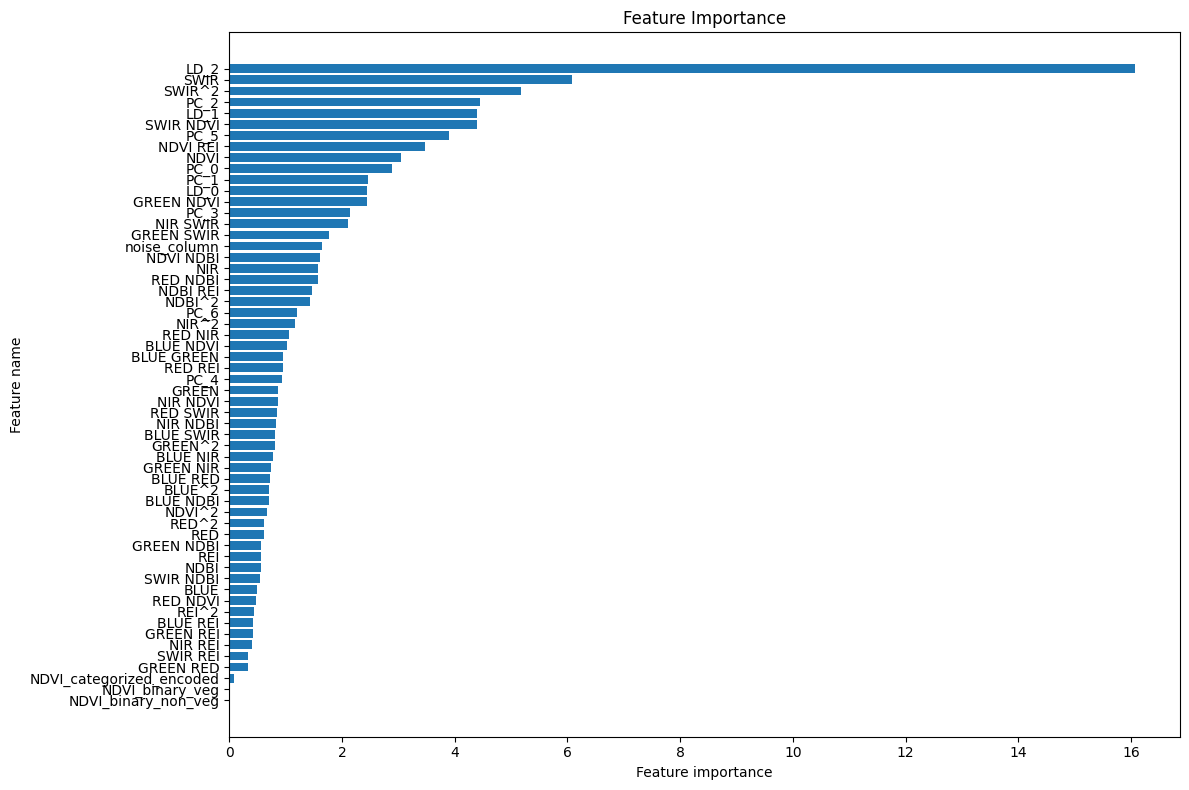

In [30]:
vis_ops.plot_feature_importance(importance_value)

In [31]:
X_train_selected = X_train_all[important_features]
X_test_selected = X_test_all[important_features]
X_train_selected.head()

,LD_2,SWIR,SWIR^2,PC_2,LD_1,SWIR NDVI,PC_5,NDVI REI,NDVI,PC_0,PC_1,LD_0,GREEN NDVI,PC_3,NIR SWIR,GREEN SWIR
0,0.484264,0.252389,0.235606,0.467035,0.809686,0.996296,0.783424,0.975468,0.998145,0.988196,0.227054,0.943724,0.991154,0.880553,0.509260,0.091881
1,0.498410,0.257980,0.240953,0.407299,0.744878,0.958564,0.666598,0.819191,0.959140,0.915317,0.250416,0.958344,0.956377,0.627907,0.482975,0.100369
2,0.312389,0.140895,0.130128,0.205550,0.831599,0.122202,0.594853,0.006760,0.117894,0.158891,0.179393,0.059399,0.139605,0.380163,0.152177,0.278998
3,0.509194,0.279338,0.261432,0.463252,0.772786,0.968075,0.654177,0.902424,0.965088,0.951035,0.255395,0.951466,0.960023,0.780107,0.520063,0.103074
4,0.352816,0.091216,0.083842,0.218314,0.808070,0.102449,0.611487,0.005167,0.098004,0.152585,0.112664,0.075903,0.116900,0.338229,0.087361,0.233143


In [32]:
# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=10000, random_state=1)
lr.fit(X_train_selected, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_selected)
y_pred_test = lr.predict(X_test_selected)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)[3]}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)[3]}")

Train Accuracy: (0.9329399141630901, 0.9335098265230241, 0.9329399141630901, 0.9331146685083637)
Test Accuracy: (0.9334763948497854, 0.9333983274266268, 0.9334763948497854, 0.9334311785885889)


END